In [25]:
#import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns

from sklearn.decomposition import PCA

In [18]:
#load the dataset
df = pd.read_csv('mobile_usage_behavioral_analysis.csv')
df.head()

,User_ID,Age,Gender,Total_App_Usage_Hours,Daily_Screen_Time_Hours,Number_of_Apps_Used,Social_Media_Usage_Hours,Productivity_App_Usage_Hours,Gaming_App_Usage_Hours,Location
0,1,56,Male,2.61,7.15,24,4.43,0.55,2.40,Los Angeles
1,2,46,Male,2.13,13.79,18,4.67,4.42,2.43,Chicago
2,3,32,Female,7.28,4.50,11,4.58,1.71,2.83,Houston
3,4,25,Female,1.20,6.29,21,3.18,3.42,4.58,Phoenix
4,5,38,Male,6.31,12.59,14,3.15,0.13,4.00,New York


In [19]:
df.info

<bound method DataFrame.info of      User_ID  Age  Gender  Total_App_Usage_Hours  Daily_Screen_Time_Hours  \
0          1   56    Male                   2.61                     7.15   
1          2   46    Male                   2.13                    13.79   
2          3   32  Female                   7.28                     4.50   
3          4   25  Female                   1.20                     6.29   
4          5   38    Male                   6.31                    12.59   
..       ...  ...     ...                    ...                      ...   
995      996   41  Female                   3.58                    12.46   
996      997   32    Male                   9.65                    10.51   
997      998   46  Female                  11.68                    10.06   
998      999   25    Male                   3.89                    10.78   
999     1000   22  Female                   3.99                     7.05   

     Number_of_Apps_Used  Social_Media_Usag

In [20]:
df.isnull().sum()


User_ID                         0
Age                             0
Gender                          0
Total_App_Usage_Hours           0
Daily_Screen_Time_Hours         0
Number_of_Apps_Used             0
Social_Media_Usage_Hours        0
Productivity_App_Usage_Hours    0
Gaming_App_Usage_Hours          0
Location                        0
dtype: int64

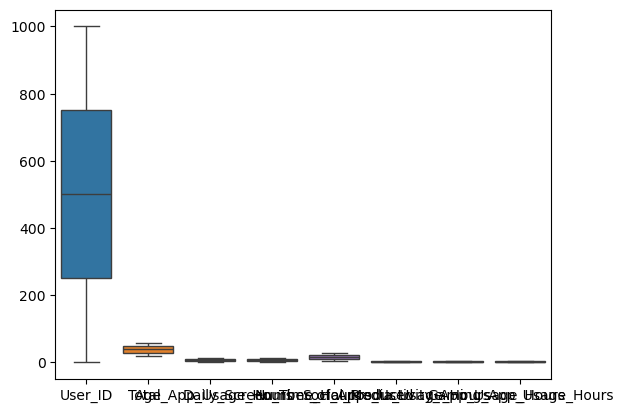

In [26]:
#outliers
sns.boxplot(data=df)
plt.show()

In [21]:
X = df[[
    'Total_App_Usage_Hours',
    'Daily_Screen_Time_Hours',
    'Number_of_Apps_Used',
    'Social_Media_Usage_Hours',
    'Productivity_App_Usage_Hours',
    'Gaming_App_Usage_Hours'
]]

In [28]:
# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


In [30]:
# Apply K-Means Clustering
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)
# Add Cluster Column
df['Cluster'] = clusters



c:\Users\kruth\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [31]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

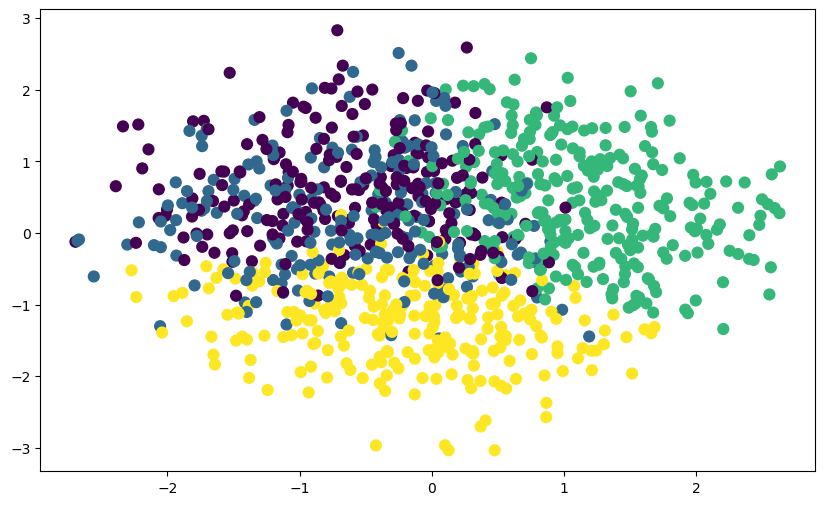

In [32]:
plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap='viridis',
    s=60
)


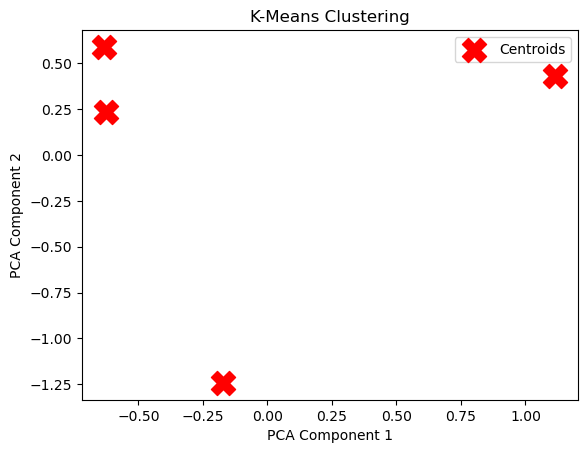

In [33]:
# Plot Centroids
centroids = pca.transform(kmeans.cluster_centers_)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c='red',
    s=300,
    marker='X',
    label='Centroids'
)

plt.title('K-Means Clustering')

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.legend()

plt.show()

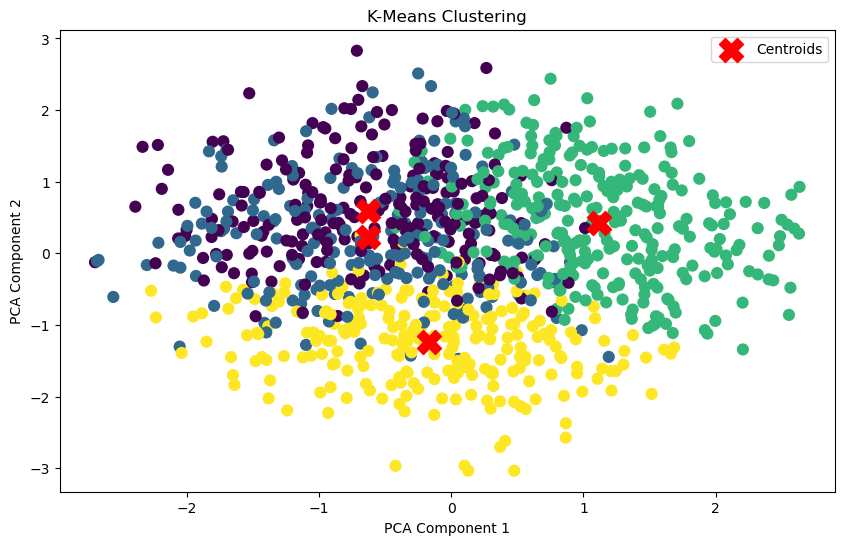

In [34]:
# Visualize Clusters
# -----------------------------
plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=clusters,
    cmap='viridis',
    s=60
)

# Plot Centroids
centroids = pca.transform(kmeans.cluster_centers_)

plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    c='red',
    s=300,
    marker='X',
    label='Centroids'
)

plt.title('K-Means Clustering')

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

plt.legend()

plt.show()


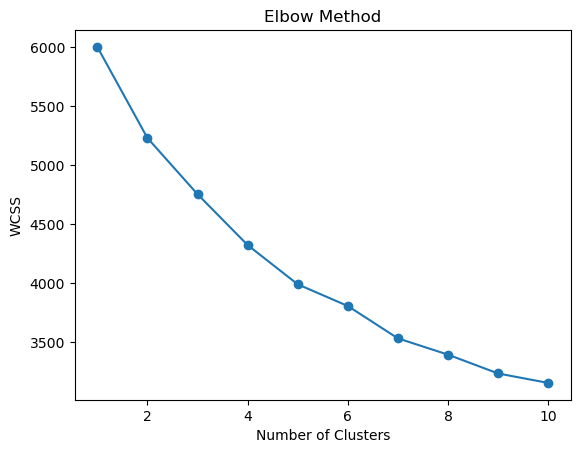

In [ ]:
plt.plot(range(1,11), wcss, marker='o')


plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.show()


In [ ]:
# Apply K-Means
kmeans = KMeans(
    n_clusters=4,
    init='k-means++',
    random_state=42
)

In [16]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Daily_Screen_Time_Hours'],
    df['Total_App_Usage_Hours'],
    c=df['Cluster'],
    cmap='viridis'
)

plt.xlabel("Daily Screen Time Hours")
plt.ylabel("Total App Usage Hours")
plt.title("User Segmentation using K-Means")

plt.show()

KeyError: 'Cluster'

<Figure size 800x600 with 0 Axes>